## 0. 배경 · 문제의식 · 목적

Part 1에서 "첫 구매 후 장바구니 재추가 여부"는 재구매와 가장 강한 연관성
(Cramér's V = 0.505)을 보인 요인이었다. Part 2 모델에서도 이 변수
(`post_cart_yn`)가 가장 큰 예측력(LR 계수 0.641, 1위)을 가졌다.

문제는 이게 상관관계라는 것. "장바구니 재추가한 사람이 재구매를 잘 한다"와
"장바구니 재추가가 재구매를 만든다"는 다른 얘기다. 둘 다 "원래 구매 의향이
높은 사람"이라는 공통 원인 때문에 같이 나타나는 것일 수도 있다.

| 질문 | 답변 여부 |
|---|---|
| 장바구니 재추가한 사람이 재구매할까? (예측) | Part 2 |
| CRM으로 장바구니 재추가를 유도하면 재구매가 늘어날까? (개입) | 아직 없음 |

교란이 사실이라면, CRM으로 장바구니 재추가를 유도해도 재구매는 안 는다.
이 파트는 그 가능성을 확인한다.

### 분석과정

1. T-Y-W 구조를 DAG로 명시 (Model)
2. Backdoor Criterion으로 식별 가능성 확인 (Identify)
3. PSM/IPW로 순수 효과(ATE) 추정 (Estimate)
4. Refutation Test로 강건성 검증 (Refute)

### 분석 대상

| 구분 | 내용 |
|---|---|
| 처치(T) | `post_cart_yn` — 첫 구매 후 7일 이내, 재구매 이전 시점의 장바구니 재추가 여부 |
| 결과(Y) | `repurchase` — 18일 이내 재구매 여부 |
| 교란요인(W) | 구매 전 조회수/장바구니 횟수, 첫 구매 가격·카테고리, 가입~첫구매 기간 |
| 방법론 | DoWhy (Model → Identify → Estimate → Refute), PSM/IPW |
| 표본 | 첫 구매 유저 332,125명 (T=1: 31,859 / T=0: 300,266) |


## 1. 데이터 준비 — T/Y/W 정의

Part 2에서 만든 `feature_df`를 그대로 쓰되, 역할을 T/Y/W로 재정의한다.

Part 2 피처 중 `post_cart_yn` 하나만 처치로 골랐다. 이유는 세 가지.

| 기준 | post_cart_yn | 다른 post-purchase 피처 |
|---|---|---|
| 개입 가능 | CRM(재입고 알림 등)으로 유도 가능 | `first_purchase_price` 등은 이미 확정된 과거 값 |
| 시간 순서 | 첫 구매 후, 재구매 이전으로 명확 | `pre_view_count` 등은 T보다 먼저 일어나 W에 더 가까움 |
| 신호 강도 | V=0.505, LR 계수 1위 | 상대적으로 약함 |

- **T**: `post_cart_yn` — 첫 구매 후 1~7일 이내, 두 번째 구매보다 반드시
  이전인 장바구니 이벤트 여부
- **Y**: `repurchase` — 18일 이내 재구매 여부
- **W**: `pre_view_count`, `pre_cart_count`, `first_purchase_price`,
  `days_to_first_purchase`, 카테고리 더미(`cat_apparel`, `cat_appliances`,
  `cat_computers`, 기준=electronics)

`post_view_yn`, `repeat_view_yn`은 T와 같은 7일 창 안에서 일어나 시간
순서가 애매해서 W에서 뺐다.

*`post_cart_yn`은 재구매가 이미 일어난 뒤의 장바구니 이벤트까지 처치로
잡는 문제가 있어서, second_purchase_time 이전으로 관측창을 제약해 다시
계산한 값을 쓴다.*

In [43]:
import pandas as pd
import numpy as np

np.random.seed(42)

# ── 0. 원본 데이터 로드 ──────────────────────────────────────
df1 = pd.read_pickle("clean_events.pkl")
df1['event_time'] = pd.to_datetime(df1['event_time'])
last_date = df1['event_time'].max()

# ── 1. 분석 대상 확정 (Part 2, N=18일 이상 관측 가능 유저) ──
purchases = df1[df1['event_type'] == 'purchase'].copy()

first_purchase = (
    purchases.groupby('user_id')['event_time']
    .min().reset_index()
    .rename(columns={'event_time': 'first_purchase_time'})
)
first_purchase['days_remaining'] = (last_date - first_purchase['first_purchase_time']).dt.days
analysis_users = first_purchase[first_purchase['days_remaining'] >= 18].copy()

purchase_counts = (
    purchases.groupby('user_id')
    .apply(lambda x: x.sort_values('event_time')['event_time'].iloc[1]
           if len(x) >= 2 else pd.NaT)
    .reset_index()
    .rename(columns={0: 'second_purchase_time'})
)
analysis_users = analysis_users.merge(purchase_counts, on='user_id', how='left')

analysis_users['days_to_repurchase'] = (
    analysis_users['second_purchase_time'] - analysis_users['first_purchase_time']
).dt.days
analysis_users['repurchase'] = (analysis_users['days_to_repurchase'] <= 18).astype(int)

first_event_time = (
    df1.groupby('user_id')['event_time'].min()
    .reset_index().rename(columns={'event_time': 'first_event_time'})
)
analysis_users = analysis_users.merge(first_event_time, on='user_id', how='left')
analysis_users['days_to_first_purchase'] = (
    analysis_users['first_purchase_time'] - analysis_users['first_event_time']
).dt.days

print(f'분석 대상 유저 수: {len(analysis_users):,}명')  # 332,125명 나와야 정상

# ── 2. Pre-purchase 피처 ─────────────────────────────────────
pre_events = df1.merge(analysis_users[['user_id', 'first_purchase_time']], on='user_id')
pre_events = pre_events[pre_events['event_time'] < pre_events['first_purchase_time']]

pre_views = (pre_events[pre_events['event_type']=='view']
             .groupby('user_id').size().reset_index()
             .rename(columns={0: 'pre_view_count'}))
pre_carts = (pre_events[pre_events['event_type']=='cart']
             .groupby('user_id').size().reset_index()
             .rename(columns={0: 'pre_cart_count'}))

first_purchase_info = (
    purchases.merge(analysis_users[['user_id', 'first_purchase_time']], on='user_id')
    .query('event_time == first_purchase_time')
    .groupby('user_id').first().reset_index()
    [['user_id', 'category_code', 'price']]
    .rename(columns={'category_code': 'first_category', 'price': 'first_purchase_price'})
)

# ── 3. Post-purchase 피처 (★ 리키지 수정된 버전 — second_purchase_time 제약 포함) ──
post_events = df1.merge(
    analysis_users[['user_id', 'first_purchase_time', 'second_purchase_time']],
    on='user_id'
)
post_events['days_after_purchase'] = (
    post_events['event_time'] - post_events['first_purchase_time']
).dt.days

post_events = post_events[
    (post_events['days_after_purchase'] > 0) &
    (post_events['days_after_purchase'] <= 7) &
    (post_events['event_type'] != 'purchase') &
    (
        post_events['second_purchase_time'].isna() |
        (post_events['event_time'] < post_events['second_purchase_time'])
    )
]

post_view_yn = (post_events[post_events['event_type']=='view']
                .groupby('user_id').size().reset_index()
                .rename(columns={0: 'post_view_count'}))
post_view_yn['post_view_yn'] = 1

post_cart_yn = (post_events[post_events['event_type']=='cart']
                .groupby('user_id').size().reset_index()
                .rename(columns={0: 'post_cart_count'}))
post_cart_yn['post_cart_yn'] = 1

first_product = (
    purchases.merge(analysis_users[['user_id', 'first_purchase_time']], on='user_id')
    .query('event_time == first_purchase_time')
    .groupby('user_id')['product_id'].first().reset_index()
    .rename(columns={'product_id': 'first_product_id'})
)
repeat_view = post_events.merge(first_product, on='user_id', how='left')
repeat_view = repeat_view[
    (repeat_view['event_type']=='view') &
    (repeat_view['product_id']==repeat_view['first_product_id'])
]
repeat_view_yn = (repeat_view.groupby('user_id').size().reset_index()
                   .rename(columns={0: 'repeat_view_count'}))
repeat_view_yn['repeat_view_yn'] = 1

# ── 4. feature_df 통합 ───────────────────────────────────────
feature_df = analysis_users[['user_id', 'repurchase', 'days_to_first_purchase']].copy()
feature_df = feature_df.merge(pre_views, on='user_id', how='left')
feature_df = feature_df.merge(pre_carts, on='user_id', how='left')
feature_df = feature_df.merge(first_purchase_info, on='user_id', how='left')
feature_df = feature_df.merge(post_view_yn[['user_id','post_view_yn','post_view_count']], on='user_id', how='left')
feature_df = feature_df.merge(post_cart_yn[['user_id','post_cart_yn','post_cart_count']], on='user_id', how='left')
feature_df = feature_df.merge(repeat_view_yn[['user_id','repeat_view_yn']], on='user_id', how='left')

fill_zero_cols = ['pre_view_count','pre_cart_count','post_view_yn','post_view_count',
                   'post_cart_yn','post_cart_count','repeat_view_yn']
feature_df[fill_zero_cols] = feature_df[fill_zero_cols].fillna(0)
feature_df['first_category'] = feature_df['first_category'].fillna('unknown')

print('post_cart_yn 합계:', feature_df['post_cart_yn'].sum())  # 31,859 나와야 정상

# ── 5. Part 3용 causal_df 구성 (T/Y/W) ───────────────────────
feature_df['first_category_top'] = (
    feature_df['first_category'].str.split('.').str[0]
)
cat_dummies = pd.get_dummies(feature_df['first_category_top'], prefix='cat')
cat_dummies = cat_dummies.drop(columns=['cat_electronics'])  # 기준 카테고리
feature_df = pd.concat([feature_df, cat_dummies], axis=1)

T_col = 'post_cart_yn'
Y_col = 'repurchase'
W_cols = ['pre_view_count','pre_cart_count','first_purchase_price',
          'days_to_first_purchase'] + cat_dummies.columns.tolist()

causal_df = feature_df[[T_col, Y_col] + W_cols].copy()
causal_df[T_col] = causal_df[T_col].astype(int)
causal_df[Y_col] = causal_df[Y_col].astype(int)

print(causal_df.shape)  # (332125, 9) 나와야 정상
print(causal_df.groupby(T_col)[Y_col].mean())  # T=0: 0.312, T=1: 0.755 나와야 정상

C:\Users\rhals\AppData\Local\Temp\ipykernel_23700\2791344606.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values('event_time')['event_time'].iloc[1]


분석 대상 유저 수: 332,125명
post_cart_yn 합계: 31859.0
(332125, 9)
post_cart_yn
0    0.312430
1    0.755077
Name: repurchase, dtype: float64


## 2. Covariate Balance Check — 두 집단은 애초에 다른 사람들이었나?

재구매율이 재추가 안 한 집단 31.2%, 재추가한 집단 75.5%로 44.3%p
차이났다. 이 차이가 행동 때문인지, 애초에 다른 사람들이라서인지 봐야 한다.

| 비교 항목 | 재추가 안 함 | 재추가 함 |
|---|---|---|
| 첫 구매까지 걸린 시간 | 4.4일 | 6.0일 |
| 구매 전 장바구니 사용 횟수 | 1.2회 | 1.6회 |
| 첫 구매 가격 | 333달러 | 370달러 |
| 가전제품 구매 비율 | 17.5% | 13.4% |

재추가한 집단(T=1)은 구매를 더 신중하게 결정하고 더 비싼 물건을 산다.
두 집단이 원래 다른 성향의 사람들일 가능성이 있고, 그렇다면 44.3%p 차이
안에 이 성향 차이가 섞여 있을 수 있다. 다음 단계에서 이걸 걷어낸다.

In [48]:
# 그룹별 W 평균 비교
balance_check = causal_df.groupby(T_col)[W_cols].mean()
print(balance_check)

# 표준화 평균 차이 (SMD)
smd_results = {}
for col in W_cols:
    mean_t1 = causal_df[causal_df[T_col]==1][col].mean()
    mean_t0 = causal_df[causal_df[T_col]==0][col].mean()
    pooled_std = causal_df[col].std()
    smd = (mean_t1 - mean_t0) / pooled_std
    smd_results[col] = round(smd, 3)

print('\n표준화 평균 차이(SMD):')
for k, v in smd_results.items():
    print(f'{k}: {v}')

              pre_view_count  pre_cart_count  first_purchase_price  \
post_cart_yn                                                         
0                  14.071320        1.223032            333.175092   
1                  15.732854        1.576509            369.606913   

              days_to_first_purchase  cat_apparel  cat_appliances  \
post_cart_yn                                                        
0                           4.365186     0.018011        0.174778   
1                           5.986409     0.012084        0.133526   

              cat_computers  
post_cart_yn                 
0                  0.053333  
1                  0.045136  

표준화 평균 차이(SMD):
pre_view_count: 0.059
pre_cart_count: 0.154
first_purchase_price: 0.11
days_to_first_purchase: 0.195
cat_apparel: -0.045
cat_appliances: -0.11
cat_computers: -0.037


## 3. Model — DAG 명시 (DoWhy)

W → T, W → Y, T → Y 구조를 `common_causes=W_cols`로 DoWhy에 넘기면
그래프가 자동으로 만들어진다. 다음 단계(Identify)에서 이 그래프를 보고
"T의 순수효과를 구하려면 뭘 통제해야 하는지" 계산한다.

W 8개가 T와 Y 양쪽으로 화살표를 뻗고 T→Y도 있는 것 확인. 의도한 구조 그대로다.

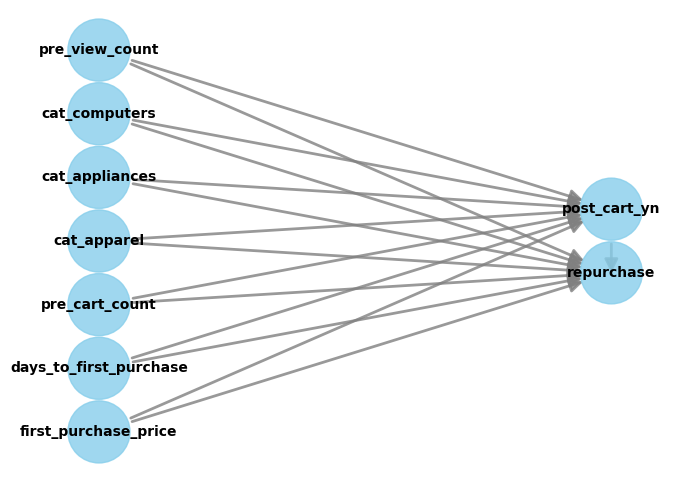

In [50]:
from dowhy import CausalModel

model = CausalModel(
    data=causal_df,
    treatment=T_col,      # 'post_cart_yn'
    outcome=Y_col,         # 'repurchase'
    common_causes=W_cols,  # 교란요인 7개 리스트
)

model.view_model()

## 4. Identify — 교란 변수만 통제하면 되나

W를 통제하면 T의 순수효과를 계산할 수 있는지 DoWhy가 수학적으로
확인해주는 단계다. W가 T와 Y 양쪽에 영향을 주는 뒷문 경로(backdoor path)가
있는데, W를 통제했을 때 이 경로가 완전히 막히는지가 관건이다. 안 막히면
PSM이든 IPW든 뭘 써도 소용없다.

### Identify 결과

Backdoor로 식별 가능함을 확인했다. 정의한 교란요인 8개를 통제하면
`post_cart_yn`의 순수효과를 계산할 수 있다.

In [52]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                                             ↪
───────────────(E[repurchase|first_purchase_price,days_to_first_purchase,pre_cart_count,cat_apparel, ↪
d[post_cart_yn]                                                                                      ↪

↪                                              
↪ cat_appliances,cat_computers,pre_view_count])
↪                                              
Estimand assumption 1, Unconfoundedness: If U→{post_cart_yn} and U→repurchase then P(repurchase|post_cart_yn,first_purchase_price,days_to_first_purchase,pre_cart_count,cat_apparel,cat_appliances,cat_computers,pre_view_count,U) = P(repurchase|post_cart_yn,first_purchase_price,days_to_first_purchase,pre_cart_count,cat_apparel,cat_appliances,cat_computers,pre_view_count)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

##

## 5. Estimate — PSM/IPW로 ATE 추정

W를 통제한 상태에서 T의 순수효과를 두 가지 방법으로 계산한다.

- **PSM**: T=1일 확률(성향점수)을 W로 예측하고, 점수가 비슷한 T=0/T=1을
  짝지어 그 차이만 본다.
- **IPW**: 짝짓기 대신 성향점수의 역수를 가중치로 써서 전체 표본을 그대로
  쓴다.

계산 원리가 다른 두 방법이 같은 답을 내는지가 포인트다.

### Estimate 결과

| 구분 | 재구매율 차이 |
|---|---|
| 통제 전 (raw) | 44.3%p |
| PSM | 45.7%p |
| IPW | 45.2%p |

교란요인을 통제해도 효과가 줄지 않았다. raw보다 부풀려져 있을 거라
예상했는데 아니었다 — 장바구니 재추가 자체가 재구매와 강하게 연결된
신호일 가능성이 높다는 뜻이다.

PSM과 IPW가 비슷한 값으로 수렴한 것도 특정 기법의 우연이 아니라는 근거다.
또한 PSM 추정치의 신뢰구간도 1.3%p 폭으로 좁아 안정적이다.

다만 이건 관측된 교란요인만 통제한 결과다. 관측 안 된 요인(실제 구매
의향 같은)이 있다면 얘기가 달라질 수 있다. 이 결과가 노이즈는 아닌지
Refutation에서 마저 확인한다.

In [53]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching"
)
print(estimate)

C:\Users\rhals\anaconda3\envs\portfolio\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                                             ↪
───────────────(E[repurchase|first_purchase_price,days_to_first_purchase,pre_cart_count,cat_apparel, ↪
d[post_cart_yn]                                                                                      ↪

↪                                              
↪ cat_appliances,cat_computers,pre_view_count])
↪                                              
Estimand assumption 1, Unconfoundedness: If U→{post_cart_yn} and U→repurchase then P(repurchase|post_cart_yn,first_purchase_price,days_to_first_purchase,pre_cart_count,cat_apparel,cat_appliances,cat_computers,pre_view_count,U) = P(repurchase|post_cart_yn,first_purchase_price,days_to_first_purchase,pre_cart_count,cat_apparel,cat_appliances,cat_computers,pre_view_count)

## Realized estim

In [ ]:
estimate_ipw = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting"
)
print(estimate_ipw)

In [57]:
ci = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    confidence_intervals=True
)
print(ci)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                                             ↪
───────────────(E[repurchase|first_purchase_price,days_to_first_purchase,pre_cart_count,cat_apparel, ↪
d[post_cart_yn]                                                                                      ↪

↪                                              
↪ cat_appliances,cat_computers,pre_view_count])
↪                                              
Estimand assumption 1, Unconfoundedness: If U→{post_cart_yn} and U→repurchase then P(repurchase|post_cart_yn,first_purchase_price,days_to_first_purchase,pre_cart_count,cat_apparel,cat_appliances,cat_computers,pre_view_count,U) = P(repurchase|post_cart_yn,first_purchase_price,days_to_first_purchase,pre_cart_count,cat_apparel,cat_appliances,cat_computers,pre_view_count)

## Realized estim

### 6-1. Placebo Treatment Test

45%p대 추정치가 진짜 신호인지, 방법론 자체의 우연인지 확인한다.

처치(장바구니 재추가)를 완전히 무작위로 섞은 가짜 처치로 바꿔서 같은
분석을 다시 돌린다. 가짜 처치는 결과랑 아무 상관 없어야 정상이니, 효과가
0에 가깝게 나와야 방법론이 제대로 작동하는 거다. 여기서도 큰 효과가
나오면 앞선 결과 전부 의심해야 한다.

**결과**

| 항목 | 값 |
|---|---|
| Estimated effect | 0.4566 |
| New effect (가짜 처치) | -0.0002 |
| p-value | 0.92 |

가짜 처치 효과가 사실상 0. p=0.92라 "0이 아니다"라고 할 근거도 없다.
방법론이 노이즈를 정확히 걸러냈다는 뜻이고, 45%p대 숫자를 믿을 근거가
하나 늘었다.

In [55]:
refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter"
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.45662325931501696
New effect:-0.0002062476477229959
p value:0.92



### 6-2. Data Subset Refuter

이번엔 다른 각도 — 이 결과가 특정 표본에만 우연히 나타난 건 아닌지 본다.

전체의 80%만 무작위로 뽑아서 같은 추정을 반복한다. 원래 값(0.4566)과
비슷하게 나오면, 일부 극단치나 특정 케이스가 아니라 데이터 전체에 퍼진
패턴이라는 뜻이다.

In [56]:
refute_subset = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8
)
print(refute_subset)

Refute: Use a subset of data
Estimated effect:0.45662325931501696
New effect:0.45619920963492666
p value:0.88



## 7. 결론

장바구니 재추가는 재구매와 인과적으로 연결된 요인일 가능성이 높다.
가격대나 구매 신중도 같은 성향 차이를 다 걷어내도 효과가 45%p대로
유지됐고, 다른 검증 방법과 표본을 적용해도 결과가 거의 바뀌지 않았다. —
적어도 내가 관측한 교란요인으로는 설명되지 않는다는 뜻이다.

CRM이 "누구에게 보낼지"뿐 아니라 "무엇을 하게 만들지"까지 설계할 근거가
생겼다는 뜻이다. Part 2가 가정한 CRM 전환율 3%에 비해, 장바구니 재추가는
재구매 확률을 45%p까지 끌어올리는 레버였다 — 재입고 알림·장바구니
리마인더처럼 재추가를 유도하는 CRM이 우선순위를 둘 만한 전략이라는
데이터 근거다.

다만 이건 관측된 교란요인 안에서의 결론이다. 민감도 분석 결과, 약한
세기(5%)의 가상 교란요인만 가정해도 추정치가 45.7%p에서 25.8%p로
낮아졌다 — 관측되지 않은 요인이 실제로 존재한다면 크기는 민감하게
반응할 수 있지만, 이 경우에도 방향성(양의 효과) 자체는 유지된다.
자연스럽게 장바구니에 담은 사람의 효과가 CRM이 억지로 유도했을 때도
똑같이 통할지는 별개 문제이며, 실제 집행 전에는 A/B 테스트로 확인이
필요하다.

| 단계 | 확인 여부 |
|---|---|
| 장바구니 재추가 ↔ 재구매, 연관 있음 | Part 1 |
| 성향 차이로 안 없어지는 신호 | Part 3 |
| CRM으로 유도해도 같은 효과 | A/B 테스트 필요 |

In [60]:
refute_unobserved = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="add_unobserved_common_cause",
    confounders_effect_on_treatment="binary_flip",
    confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=0.05,
    effect_strength_on_outcome=0.05
)
print(refute_unobserved)

Refute: Add an Unobserved Common Cause
Estimated effect:0.45662325931501696
New effect:0.25766562163392603

